In [1]:
import datetime

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from optionanalytics.data.yahoo import fetch_option_chain
from optionanalytics.cleaning.filters import clean_option_chain
from optionanalytics.cleaning.arbitrage import filter_price_bound_violations
from optionanalytics.models.market import MarketData
from optionanalytics.volatility.smile import build_smile

ticker = "AAPL"
expiry = "2026-08-21"

valuation_date = datetime.date(2026, 7, 18)

market_data = MarketData(
    spot=333.74,
    risk_free_rate=0.0418,
    volatility=0.20,      # Placeholder
)

In [2]:
chain = fetch_option_chain(ticker, expiry)

clean_chain = clean_option_chain(chain)

clean_chain = filter_price_bound_violations(
    clean_chain,
    market_data,
    valuation_date,
)

smile = build_smile(
    clean_chain,
    market_data,
    valuation_date,
)

In [3]:
def forward_price(
    market_data: MarketData,
    maturity: float,
) -> float:
    return (
        market_data.spot
        * np.exp(market_data.risk_free_rate * maturity)
    )

def log_moneyness(
    strike: float,
    forward: float,
) -> float:
    return np.log(strike / forward)

In [4]:
def total_variance(k, params):
    x = k - params.m

    return (
        params.a
        + params.b
        * (
            params.rho * x
            + np.sqrt(x**2 + params.sigma**2)
        )
    )

Text(0.5, 1.0, 'Raw SVI Total Variance')

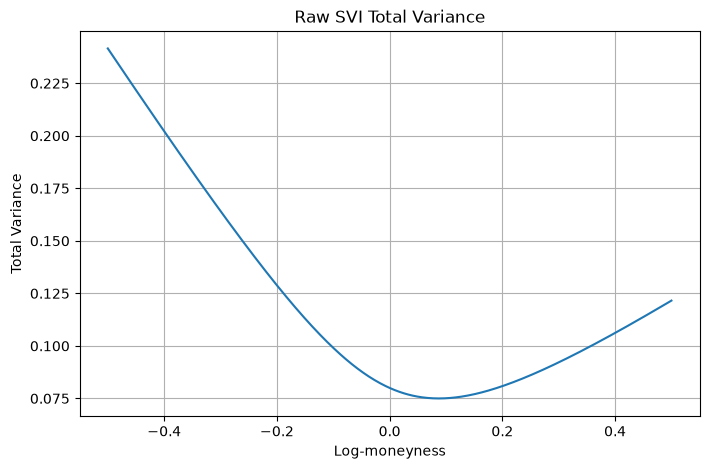

In [5]:
from optionanalytics.models.svi import SVIParameters
params = SVIParameters(
    a=0.02,
    b=0.30,
    rho=-0.40,
    m=0.0,
    sigma=0.20,
)

k = np.linspace(-0.5, 0.5, 500)

w = total_variance(k, params)

plt.figure(figsize=(8,5))
plt.plot(k, w)
plt.grid(True)

plt.xlabel("Log-moneyness")
plt.ylabel("Total Variance")
plt.title("Raw SVI Total Variance")

In [6]:
from optionanalytics.utils.dates import year_fraction

T = year_fraction(
    expiry=smile.expiry,
    valuation_date=valuation_date,
)

Text(0.5, 1.0, 'SVI Implied Volatility')

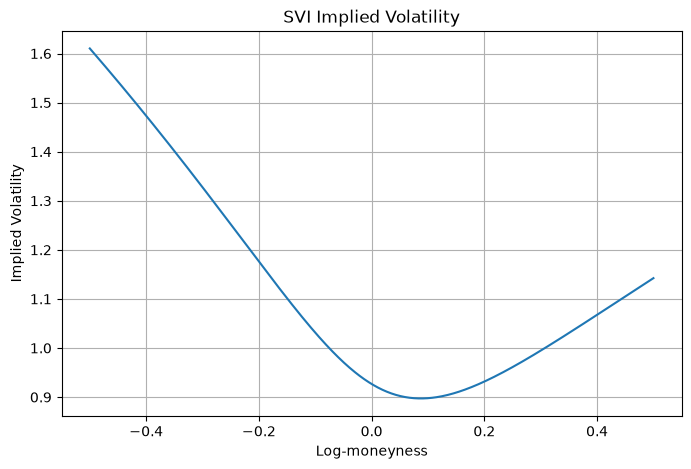

In [7]:
iv = np.sqrt(w / T)

plt.figure(figsize=(8,5))
plt.plot(k, iv)

plt.grid(True)

plt.xlabel("Log-moneyness")
plt.ylabel("Implied Volatility")
plt.title("SVI Implied Volatility")

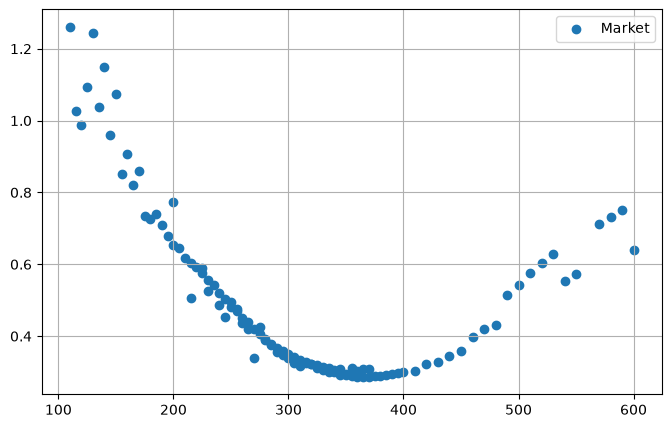

In [8]:
market_strikes = np.array(
    [p.strike for p in smile.points]
)

market_iv = np.array(
    [p.implied_volatility for p in smile.points]
)

plt.figure(figsize=(8,5))

plt.scatter(
    market_strikes,
    market_iv,
    label="Market",
)

plt.grid(True)
plt.legend()

Text(0.5, 1.0, 'Market Smile in SVI Coordinates')

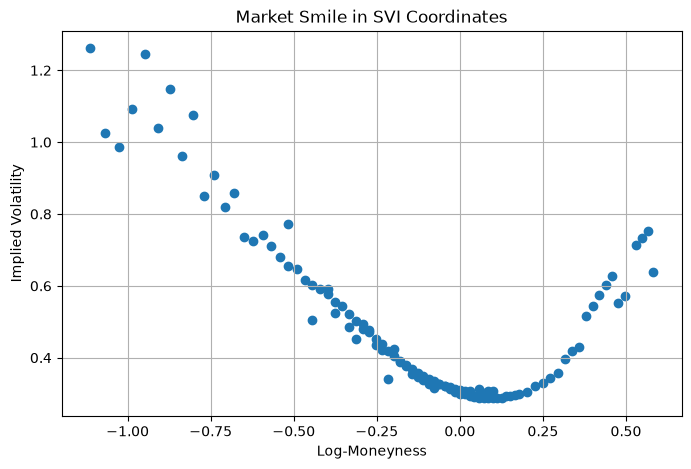

In [9]:
from optionanalytics.utils.dates import year_fraction

T = year_fraction(
    expiry=smile.expiry,
    valuation_date=valuation_date,
)

forward = (
    market_data.spot
    * np.exp(market_data.risk_free_rate * T)
)

market_k = np.log(
    market_strikes / forward
)

plt.figure(figsize=(8,5))

plt.scatter(
    market_k,
    market_iv,
)

plt.grid(True)

plt.xlabel("Log-Moneyness")
plt.ylabel("Implied Volatility")
plt.title("Market Smile in SVI Coordinates")

In [10]:
print(f"Spot    : {market_data.spot:.2f}")
print(f"Forward : {forward:.2f}")
print(f"Maturity: {T:.4f}")
print(f"Min k   : {market_k.min():.3f}")
print(f"Max k   : {market_k.max():.3f}")

Spot    : 333.74
Forward : 335.04
Maturity: 0.0932
Min k   : -1.114
Max k   : 0.583


Text(0.5, 1.0, 'Effect of parameter a (lifts up as a increases)')

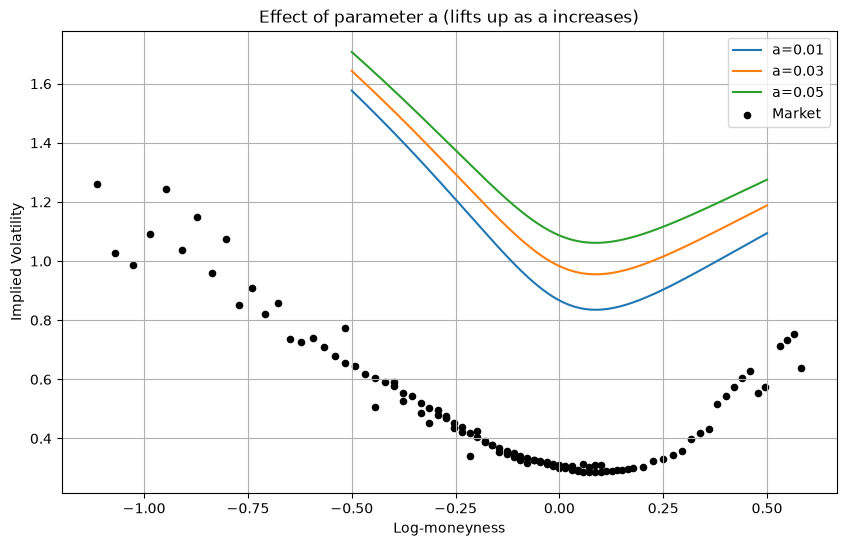

In [22]:
params = SVIParameters(
    a=0.02,
    b=0.30,
    rho=-0.40,
    m=0.00,
    sigma=0.20,
)

k = np.linspace(-0.5, 0.5, 500)

plt.figure(figsize=(10, 6))

for value in [0.01, 0.03, 0.05]:
    params.a = value
    w = total_variance(k, params)
    iv = np.sqrt(w / T)
    plt.plot(k, iv, label=f"a={value}")

plt.scatter(market_k, market_iv, color="black", s=20, label="Market")

plt.grid(True)
plt.legend()
plt.xlabel("Log-moneyness")
plt.ylabel("Implied Volatility")
plt.title("Effect of parameter a (lifts up as a increases)")

Text(0.5, 1.0, 'Effect of parameter b (curvature increases as b increases)')

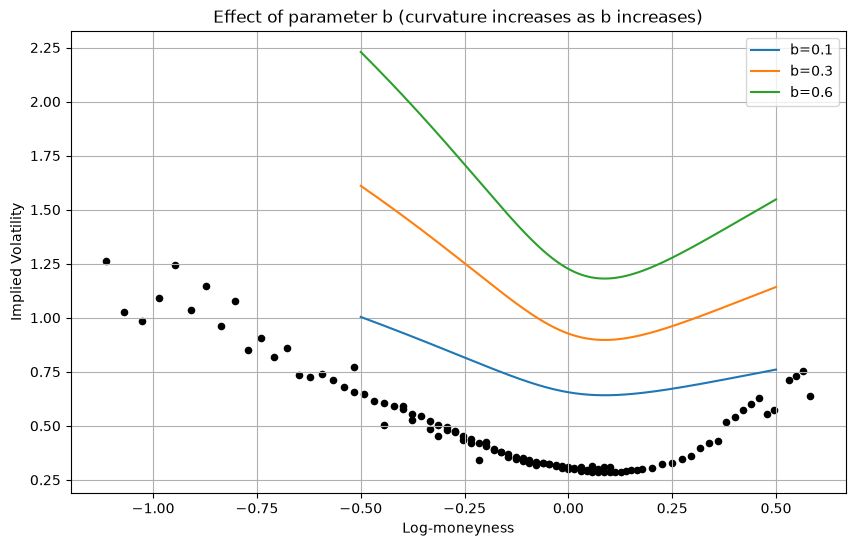

In [23]:
params = SVIParameters(
    a=0.02,
    b=0.30,
    rho=-0.40,
    m=0.00,
    sigma=0.20,
)

plt.figure(figsize=(10,6))

for value in [0.10, 0.30, 0.60]:
    params.b = value
    w = total_variance(k, params)
    iv = np.sqrt(w / T)
    plt.plot(k, iv, label=f"b={value}")

plt.scatter(market_k, market_iv, color="black", s=20)

plt.grid(True)
plt.legend()
plt.xlabel("Log-moneyness")
plt.ylabel("Implied Volatility")
plt.title("Effect of parameter b (curvature increases as b increases)")

Text(0.5, 1.0, 'Effect of parameter rho (skewness)')

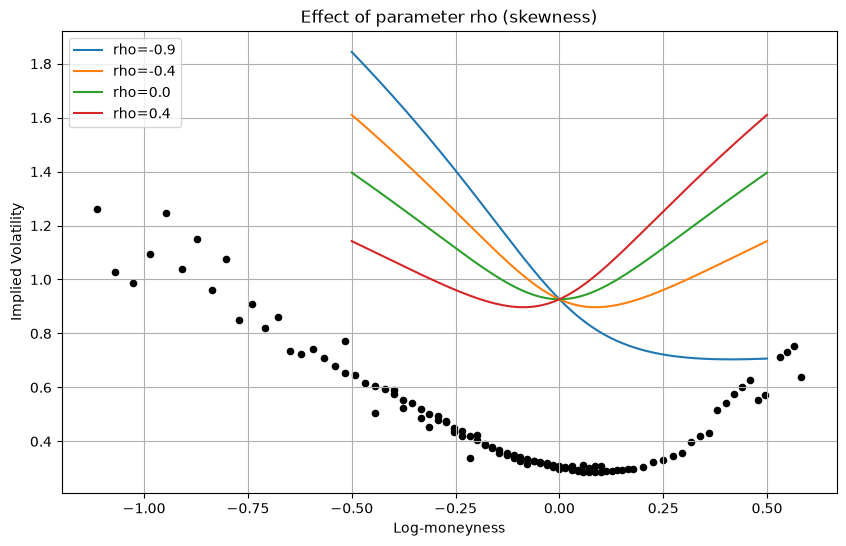

In [24]:
params = SVIParameters(
    a=0.02,
    b=0.30,
    rho=-0.40,
    m=0.00,
    sigma=0.20,
)

plt.figure(figsize=(10,6))

for value in [-0.9, -0.4, 0.0, 0.4]:
    params.rho = value
    w = total_variance(k, params)
    iv = np.sqrt(w / T)
    plt.plot(k, iv, label=f"rho={value}")

plt.scatter(market_k, market_iv, color="black", s=20)

plt.grid(True)
plt.legend()
plt.xlabel("Log-moneyness")
plt.ylabel("Implied Volatility")
plt.title("Effect of parameter rho (skewness)")

Text(0.5, 1.0, 'Effect of parameter m (moves the smile horizontally)')

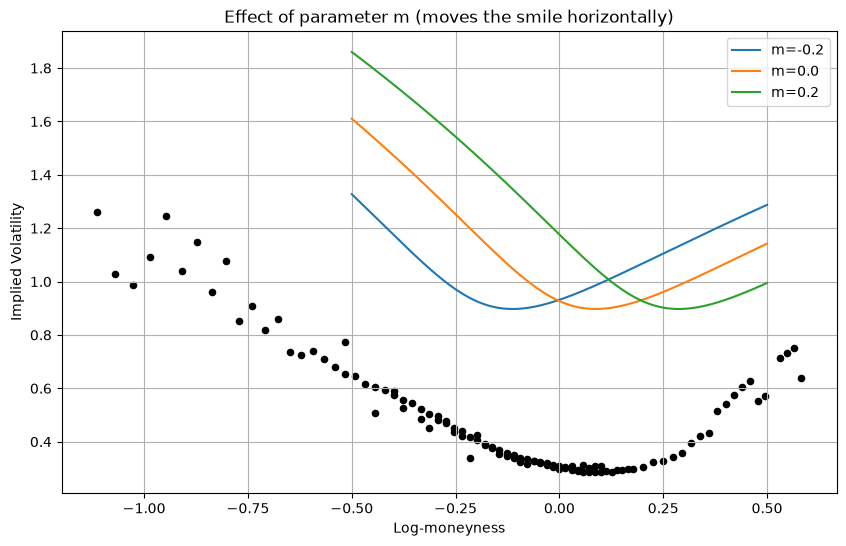

In [25]:
params = SVIParameters(
    a=0.02,
    b=0.30,
    rho=-0.40,
    m=0.00,
    sigma=0.20,
)

plt.figure(figsize=(10,6))

for value in [-0.20, 0.0, 0.20]:
    params.m = value
    w = total_variance(k, params)
    iv = np.sqrt(w / T)
    plt.plot(k, iv, label=f"m={value}")

plt.scatter(market_k, market_iv, color="black", s=20)

plt.grid(True)
plt.legend()
plt.xlabel("Log-moneyness")
plt.ylabel("Implied Volatility")
plt.title("Effect of parameter m (moves the smile horizontally)")

Text(0.5, 1.0, 'Effect of parameter sigma (controls smoothness/width around the minimum)')

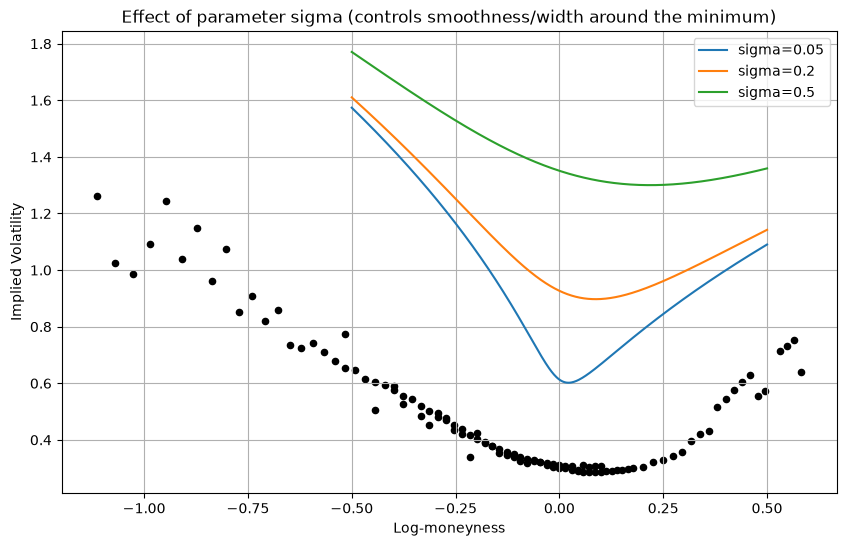

In [26]:
params = SVIParameters(
    a=0.02,
    b=0.30,
    rho=-0.40,
    m=0.00,
    sigma=0.20,
)

plt.figure(figsize=(10,6))

for value in [0.05, 0.20, 0.50]:
    params.sigma = value
    w = total_variance(k, params)
    iv = np.sqrt(w / T)
    plt.plot(k, iv, label=f"sigma={value}")

plt.scatter(market_k, market_iv, color="black", s=20)

plt.grid(True)
plt.legend()
plt.xlabel("Log-moneyness")
plt.ylabel("Implied Volatility")
plt.title("Effect of parameter sigma (controls smoothness/width around the minimum)")

Text(0.5, 1.0, 'Manual SVI Fit')

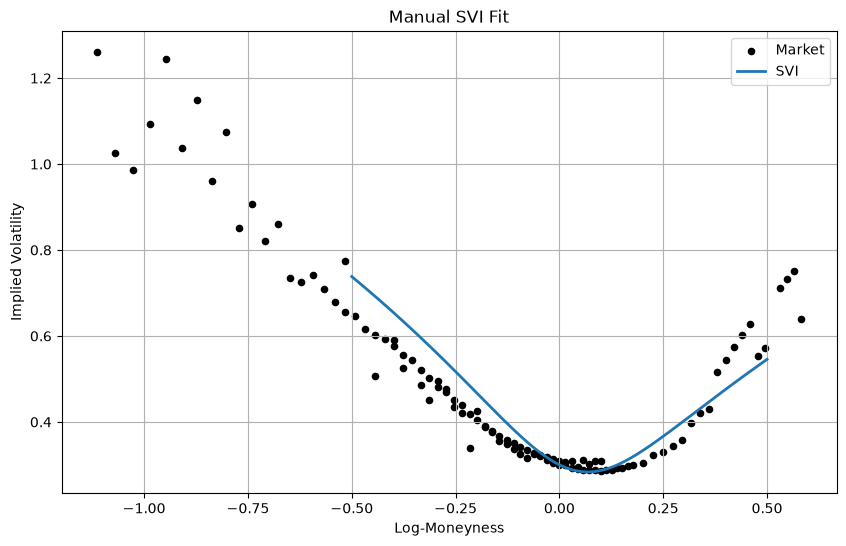

In [71]:
## Manual trying by tweaking each to fit the graph as close as possible.

params = SVIParameters(
    a=-0.017,
    b=0.1,
    rho=-0.2,
    m=0.017,
    sigma=0.25,
)

w = total_variance(k, params)
iv = np.sqrt(w / T)

plt.figure(figsize=(10,6))

plt.scatter(
    market_k,
    market_iv,
    color="black",
    s=20,
    label="Market",
)

plt.plot(
    k,
    iv,
    linewidth=2,
    label="SVI",
)

plt.grid(True)
plt.legend()
plt.xlabel("Log-Moneyness")
plt.ylabel("Implied Volatility")
plt.title("Manual SVI Fit")

### Using scipy.optimize to get closest SVI Params

In [72]:
from scipy.optimize import minimize

market_w = market_iv**2 * T

def objective(x):
    params = SVIParameters(
        a=x[0],
        b=x[1],
        rho=x[2],
        m=x[3],
        sigma=x[4],
    )

    model_w = total_variance(
        market_k,
        params,
    )

    return np.sum(
        (model_w - market_w)**2
    )

In [73]:
x0 = np.array([
    params.a,
    params.b,
    params.rho,
    params.m,
    params.sigma,
])

In [80]:
bounds = [
    (None, None),        # a
    (0.0, None),        # b
    (-0.999, 0.999),    # rho
    (None, None),       # m
    (1e-6, None),       # sigma
]

In [81]:
result = minimize(
    objective,
    x0=x0,
    bounds=bounds,
    method="L-BFGS-B",
)

result.success

True

In [82]:
opt = SVIParameters(
    a=result.x[0],
    b=result.x[1],
    rho=result.x[2],
    m=result.x[3],
    sigma=result.x[4],
)

opt

SVIParameters(a=np.float64(-0.28227533975392877), b=np.float64(0.29411849326098594), rho=np.float64(0.20128544977149268), m=np.float64(0.24997171805369975), sigma=np.float64(1.0047389474131647))

Text(0.5, 1.0, 'SVI Calibration')

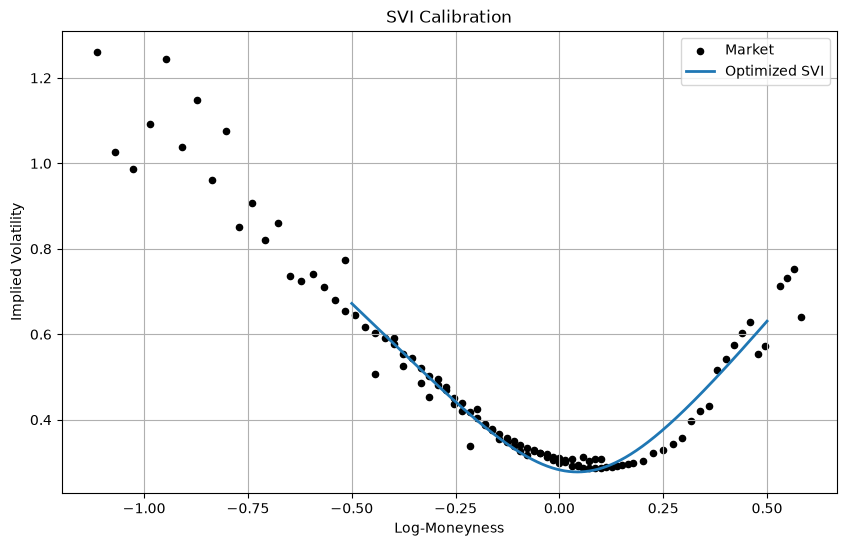

In [83]:
w = total_variance(
    k,
    opt,
)

iv = np.sqrt(w / T)

plt.figure(figsize=(10,6))

plt.scatter(
    market_k,
    market_iv,
    s=20,
    color="black",
    label="Market",
)

plt.plot(
    k,
    iv,
    linewidth=2,
    label="Optimized SVI",
)

plt.grid(True)
plt.legend()
plt.xlabel("Log-Moneyness")
plt.ylabel("Implied Volatility")
plt.title("SVI Calibration")

In [86]:
print(result)

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 0.006003842103058103
        x: [-2.823e-01  2.941e-01  2.013e-01  2.500e-01  1.005e+00]
      nit: 92
      jac: [ 1.089e-03  1.100e-03 -1.430e-04  6.402e-05  2.893e-04]
     nfev: 714
     njev: 119
 hess_inv: <5x5 LbfgsInvHessProduct with dtype=float64>


#### Synthetic data - Recovery analysis

True
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

Ground Truth
SVIParameters(a=-0.05, b=0.3, rho=-0.4, m=0.0, sigma=0.2)

Recovered
SVIParameters(a=np.float64(-0.049965783121555765), b=np.float64(0.2999246624268356), rho=np.float64(-0.40015511050436875), m=np.float64(-2.472042726454601e-05), sigma=np.float64(0.19996077108939797))


Text(0.5, 1.0, 'SVI Recovery Test')

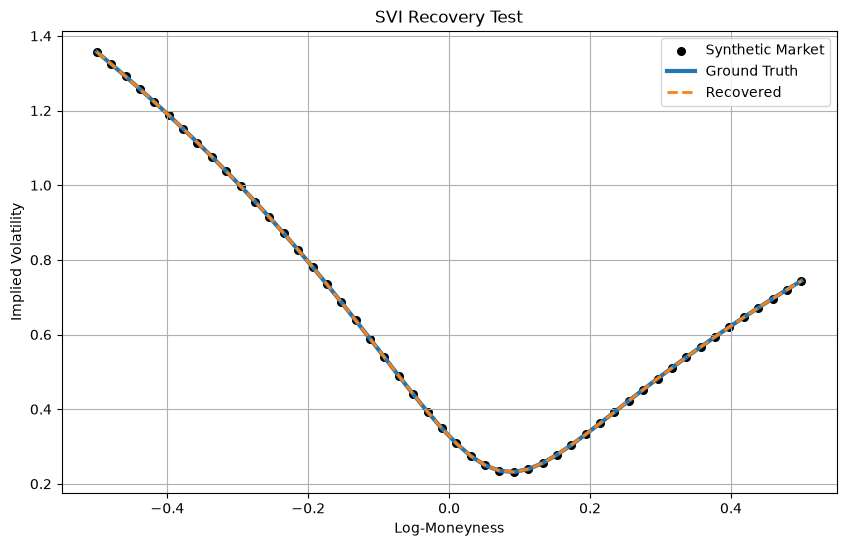

In [89]:
from scipy.optimize import minimize

# ----------------------------
# Ground truth SVI parameters
# ----------------------------
true = SVIParameters(
    a=-0.05,
    b=0.30,
    rho=-0.40,
    m=0.00,
    sigma=0.20,
)

# ----------------------------
# Generate synthetic market
# ----------------------------
k = np.linspace(-0.5, 0.5, 50)

market_w = total_variance(k, true)
market_iv = np.sqrt(market_w / T)

# Uncomment to simulate market noise
# rng = np.random.default_rng(42)
# market_iv += rng.normal(0.0, 0.003, size=market_iv.shape)

market_w = market_iv**2 * T


# ----------------------------
# Objective function
# ----------------------------
def objective(x):

    params = SVIParameters(
        a=x[0],
        b=x[1],
        rho=x[2],
        m=x[3],
        sigma=x[4],
    )

    model_w = total_variance(k, params)

    return np.sum(
        (model_w - market_w) ** 2
    )


# ----------------------------
# Initial guess
# ----------------------------
x0 = np.array([
    -0.02,
    0.20,
    -0.20,
    0.10,
    0.30,
])


# ----------------------------
# Bounds
# ----------------------------
bounds = [
    (None, None),      # a
    (0.0, None),       # b
    (-0.999, 0.999),   # rho
    (None, None),      # m
    (1e-6, None),      # sigma
]


# ----------------------------
# Optimize
# ----------------------------
result = minimize(
    objective,
    x0=x0,
    bounds=bounds,
    method="L-BFGS-B",
)


# ----------------------------
# Recover parameters
# ----------------------------
fitted = SVIParameters(
    a=result.x[0],
    b=result.x[1],
    rho=result.x[2],
    m=result.x[3],
    sigma=result.x[4],
)

print(result.success)
print(result.message)

print("\nGround Truth")
print(true)

print("\nRecovered")
print(fitted)


# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(10,6))

plt.scatter(
    k,
    market_iv,
    s=30,
    color="black",
    label="Synthetic Market",
)

plt.plot(
    k,
    np.sqrt(total_variance(k, true) / T),
    linewidth=3,
    label="Ground Truth",
)

plt.plot(
    k,
    np.sqrt(total_variance(k, fitted) / T),
    linewidth=2,
    linestyle="--",
    label="Recovered",
)

plt.grid(True)
plt.xlabel("Log-Moneyness")
plt.ylabel("Implied Volatility")
plt.legend()
plt.title("SVI Recovery Test")